Loaded YOLO from best.pt and CNN from custom.keras


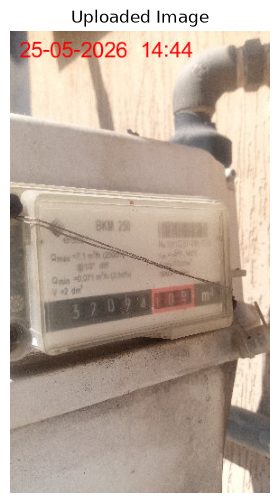

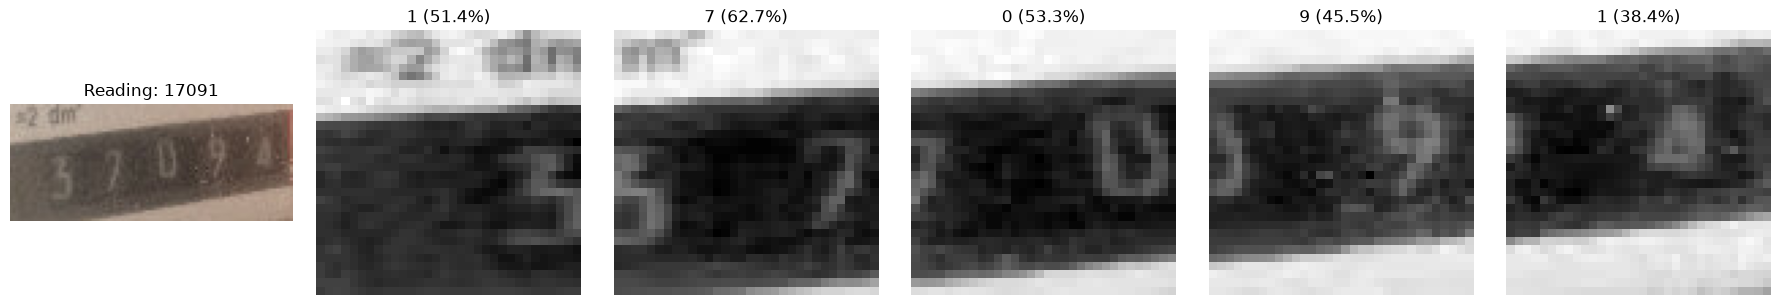


Predicted Reading: 17091
Digit Confidences: [      51.42       62.74       53.32        45.5       38.38]


In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog
import tensorflow as tf
from ultralytics import YOLO

# ========================= CONFIG =========================
NUM_DIGITS = 5
DIGIT_HEIGHT = 32
DIGIT_WIDTH = 32
BOX_PADDING_PX = 2

MIN_COMPONENT_AREA_FRAC = 0.01
MAX_COMPONENT_AREA_FRAC = 0.60

# "box middle size" tolerance band -- how far a box's height/width is
# allowed to deviate from the median before it's treated as an exception
# (noise, glare, a partial/broken stroke) rather than a real digit.
HEIGHT_TOL_LOW = 0.5
HEIGHT_TOL_HIGH = 1.6
WIDTH_TOL_LOW = 0.3
WIDTH_TOL_HIGH = 1.8

MERGE_GAP_FRAC = 0.15      # merge components closer than this * median_width
SPLIT_WIDTH_FACTOR = 1.6   # split components wider than this * median_width

USE_ADAPTIVE_THRESHOLD = False  # flip to True to A/B test on your failing images

# EDIT THESE to your actual paths
YOLO_MODEL_PATH = r"best.pt"
CNN_MODEL_PATH = "custom.keras"


# ========================= LOAD MODELS (separate names -- do not both call these "model") =========================
if not os.path.exists(YOLO_MODEL_PATH):
    raise FileNotFoundError(f"Can't find YOLO weights at {YOLO_MODEL_PATH}")
if not os.path.exists(CNN_MODEL_PATH):
    raise FileNotFoundError(f"Can't find CNN model at {CNN_MODEL_PATH}")

yolo_model = YOLO(YOLO_MODEL_PATH)
digit_model = tf.keras.models.load_model(CNN_MODEL_PATH, compile=False)
print(f"Loaded YOLO from {YOLO_MODEL_PATH} and CNN from {CNN_MODEL_PATH}")


# ========================= YOLO: DETECT ROI =========================
def get_meter_roi(image, yolo_model=yolo_model, conf=0.25):
    """Runs YOLO on `image` (path or BGR array), returns the highest-confidence
    bounding box cropped out as a BGR array. None if nothing detected."""
    result = yolo_model.predict(source=image, imgsz=640, conf=conf, verbose=False)[0]

    if len(result.boxes) == 0:
        return None

    boxes = result.boxes.xyxy.cpu().numpy().astype(int)
    confidences = result.boxes.conf.cpu().numpy()
    x1, y1, x2, y2 = boxes[int(np.argmax(confidences))]

    roi = result.orig_img[y1:y2, x1:x2]
    return roi if roi.size > 0 else None


# =========================================================================
# DIGIT SEGMENTATION -- connected component method from Son et al.,
# "Deep Learning-based Number Detection and Recognition for Gas Meter
# Reading" (IEIE TSPC, 2019), Fig. 4 pipeline: filter+binarize ->
# connected components -> exception processing (box middle size) ->
# rescale. Merge/split steps added on top for fragmented/touching digits.
# =========================================================================

def preprocess_reading_area(gray_img, use_adaptive=False, use_clahe=True):
    """(a)->(b) in Fig. 4: filtering + binarization."""
    img = gray_img.copy()

    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)

    denoised = cv2.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)

    if use_adaptive:
        binary = cv2.adaptiveThreshold(
            denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, blockSize=25, C=7
        )
    else:
        _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if np.mean(binary == 255) > 0.5:
        binary = cv2.bitwise_not(binary)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary


def connected_component_boxes(binary_img):
    """(c) in Fig. 4: connected component labeling."""
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_img, connectivity=8)
    boxes = []
    img_area = binary_img.shape[0] * binary_img.shape[1]
    for label_id in range(1, num_labels):  # skip background label 0
        x, y, w, h, area = stats[label_id]
        area_frac = area / img_area
        if MIN_COMPONENT_AREA_FRAC <= area_frac <= MAX_COMPONENT_AREA_FRAC:
            boxes.append((x, y, w, h))
    boxes.sort(key=lambda b: b[0])
    return boxes


def exception_process_by_box_middle_size(boxes):
    """Paper's 'exception processing and box middle size are referenced'
    step. Real digits share a similar height/width; anything well outside
    the median band (noise, glare, a broken stroke) is dropped."""
    if len(boxes) == 0:
        return boxes
    median_h = np.median([b[3] for b in boxes])
    return [b for b in boxes if HEIGHT_TOL_LOW * median_h <= b[3] <= HEIGHT_TOL_HIGH * median_h]


def merge_fragmented_boxes(boxes):
    """Merge components that sit close together horizontally -- handles a
    single digit whose stroke got broken into two components by glare or
    a thin joint that thresholding erased."""
    if len(boxes) <= 1:
        return boxes
    median_w = np.median([b[2] for b in boxes])
    boxes = sorted(boxes, key=lambda b: b[0])
    merged = [boxes[0]]
    for b in boxes[1:]:
        px, py, pw, ph = merged[-1]
        x, y, w, h = b
        gap = x - (px + pw)
        if gap < MERGE_GAP_FRAC * median_w:
            nx0, ny0 = min(px, x), min(py, y)
            nx1, ny1 = max(px + pw, x + w), max(py + ph, y + h)
            merged[-1] = (nx0, ny0, nx1 - nx0, ny1 - ny0)
        else:
            merged.append(b)
    return merged


def split_merged_box(binary_crop, expected_splits):
    """Ink-density valley split for touching/merged digits."""
    col_sums = binary_crop.sum(axis=0)
    w = binary_crop.shape[1]
    seg_width = max(1, w // expected_splits)

    split_points = [0]
    for i in range(1, expected_splits):
        approx = i * seg_width
        lo = max(0, approx - seg_width // 3)
        hi = min(w, approx + seg_width // 3)
        window = col_sums[lo:hi]
        if len(window) == 0:
            split_points.append(approx)
            continue
        split_points.append(lo + int(np.argmin(window)))
    split_points.append(w)

    split_points = sorted(set(split_points))
    if len(split_points) < expected_splits + 1:
        split_points = [int(i * w / expected_splits) for i in range(expected_splits + 1)]

    return [(split_points[i], split_points[i + 1]) for i in range(len(split_points) - 1)]


def split_oversized_boxes(boxes, binary_img, num_digits):
    if len(boxes) == 0:
        return boxes
    median_w = np.median([b[2] for b in boxes])
    new_boxes = []
    for (x, y, w, h) in boxes:
        if median_w > 0 and w > median_w * SPLIT_WIDTH_FACTOR:
            n_merged = min(max(2, round(w / median_w)), num_digits)
            sub_crop = binary_img[y:y + h, x:x + w]
            for (sx0, sx1) in split_merged_box(sub_crop, n_merged):
                new_boxes.append((x + sx0, y, sx1 - sx0, h))
        else:
            new_boxes.append((x, y, w, h))
    new_boxes.sort(key=lambda b: b[0])
    return new_boxes


def rescale_to_common_band(boxes, img_shape):
    """(d) in Fig. 4: 'rescale process ... to detect the final number
    area.' Snap every box's vertical extent to the union band of all
    boxes, since digits share a baseline -- recovers a digit that lost a
    top/bottom pixel row to thresholding."""
    if len(boxes) == 0:
        return boxes
    y0 = max(0, min(b[1] for b in boxes) - 1)
    y1 = min(img_shape[0], max(b[1] + b[3] for b in boxes) + 1)
    return [(x, y0, w, y1 - y0) for (x, y, w, h) in boxes]


def segment_digit_boxes_reading_area(gray_img, num_digits=NUM_DIGITS, use_adaptive=USE_ADAPTIVE_THRESHOLD):
    """Full pipeline matching paper Fig. 4 (a)->(b)->(c)->(d)."""
    h_img, w_img = gray_img.shape[:2]
    binary = preprocess_reading_area(gray_img, use_adaptive=use_adaptive)

    boxes = connected_component_boxes(binary)
    boxes = exception_process_by_box_middle_size(boxes)
    boxes = merge_fragmented_boxes(boxes)
    boxes = split_oversized_boxes(boxes, binary, num_digits)
    boxes = exception_process_by_box_middle_size(boxes)  # re-check post merge/split
    boxes = rescale_to_common_band(boxes, gray_img.shape)

    if len(boxes) == num_digits:
        return boxes

    if len(boxes) > num_digits:
        # Keep the num_digits boxes closest to median shape, not just the
        # largest by area -- favors "digit-shaped" over "big blob".
        median_w = np.median([b[2] for b in boxes])
        median_h = np.median([b[3] for b in boxes])

        def shape_score(b):
            return abs(b[2] - median_w) + abs(b[3] - median_h)

        boxes = sorted(boxes, key=shape_score)[:num_digits]
        boxes.sort(key=lambda b: b[0])
        return boxes

    # Last-resort fallback only -- equal-width slicing throws away all the
    # segmentation work above; a hit here means go inspect that image with
    # debug_show_segmentation_stages().
    col_w = w_img // num_digits
    return [(i * col_w, 0, col_w, h_img) for i in range(num_digits)]


def extract_digit_crops(gray_img, boxes, target_size=(DIGIT_HEIGHT, DIGIT_WIDTH)):
    h_img, w_img = gray_img.shape[:2]
    crops = []
    for (x, y, w, h) in boxes:
        x0 = max(0, x - BOX_PADDING_PX)
        y0 = max(0, y - BOX_PADDING_PX)
        x1 = min(w_img, x + w + BOX_PADDING_PX)
        y1 = min(h_img, y + h + BOX_PADDING_PX)

        crop = gray_img[y0:y1, x0:x1]
        if crop.size == 0:
            crop = np.zeros((target_size[0], target_size[1]), dtype=np.uint8)

        crop = cv2.resize(crop, (target_size[1], target_size[0]))
        crop = crop.astype(np.float32) / 255.0
        crops.append(np.expand_dims(crop, axis=-1))
    return crops


def debug_show_segmentation_stages(image_path, num_digits=NUM_DIGITS, use_adaptive=USE_ADAPTIVE_THRESHOLD):
    """Shows boxes at every stage (raw components -> after exceptions ->
    after merge -> after split -> final) so you can see exactly which
    stage discards or misplaces a digit on a failing image."""
    from PIL import Image, ImageDraw

    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        raise FileNotFoundError(f"Could not load image:\n{image_path}")

    binary = preprocess_reading_area(gray_img, use_adaptive=use_adaptive)
    raw = connected_component_boxes(binary)
    after_exc = exception_process_by_box_middle_size(raw)
    after_merge = merge_fragmented_boxes(after_exc)
    after_split = split_oversized_boxes(after_merge, binary, num_digits)
    final_boxes = segment_digit_boxes_reading_area(gray_img, num_digits, use_adaptive)

    stages = [("raw components", raw), ("after exceptions", after_exc),
              ("after merge", after_merge), ("after split", after_split),
              ("final", final_boxes)]

    fig, axes = plt.subplots(1, len(stages), figsize=(3.5 * len(stages), 4))
    for ax, (title, boxes) in zip(axes, stages):
        annotated = Image.fromarray(gray_img).convert("RGB")
        draw = ImageDraw.Draw(annotated)
        for (x, y, w, h) in boxes:
            draw.rectangle([(x, y), (x + w, y + h)], outline="lime", width=1)
        ax.imshow(annotated)
        ax.set_title(f"{title} ({len(boxes)})")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return final_boxes


# ========================= READ METER (segmentation + recognition) =========================
def read_meter_from_roi(roi_bgr, num_digits=NUM_DIGITS, model=digit_model,
                         use_adaptive=USE_ADAPTIVE_THRESHOLD):
    """Takes the YOLO-cropped ROI (BGR array), segments it into individual
    digits using the paper's connected-component pipeline, classifies each,
    and displays the result."""
    gray_img = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    boxes = segment_digit_boxes_reading_area(gray_img, num_digits=num_digits, use_adaptive=use_adaptive)
    crops = extract_digit_crops(gray_img, boxes, target_size=(DIGIT_HEIGHT, DIGIT_WIDTH))

    batch = np.stack(crops, axis=0)  # (num_digits, H, W, 1)
    preds = model.predict(batch, verbose=0)
    digit_predictions = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1) * 100

    final_reading = "".join(map(str, digit_predictions))

    fig, axes = plt.subplots(1, num_digits + 1, figsize=(3 * (num_digits + 1), 3))
    axes[0].imshow(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Reading: {final_reading}")
    axes[0].axis("off")

    for i, crop in enumerate(crops):
        axes[i + 1].imshow(crop.squeeze(), cmap="gray")
        axes[i + 1].set_title(f"{digit_predictions[i]} ({confidences[i]:.1f}%)")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

    return final_reading, confidences


# ========================= FILE UPLOAD DIALOG =========================
def upload_image():
    """Open a file dialog and return the selected image path."""
    root = Tk()
    root.withdraw()          # Hide the Tkinter window
    root.attributes("-topmost", True)

    file_path = filedialog.askopenfilename(
        title="Select Meter Image",
        filetypes=[
            ("Image Files", "*.jpg *.jpeg *.png *.bmp *.tif *.tiff"),
            ("All Files", "*.*")
        ]
    )

    root.destroy()

    if not file_path:
        return None

    return file_path


# ========================= DISPLAY HELPER =========================
def show_original_image(image_path):
    """Displays the raw uploaded image before any detection/cropping runs."""
    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Could not load image:\n{image_path}")

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()


# ========================= MAIN =========================
if __name__ == "__main__":
    image_path = upload_image()

    if image_path is None:
        print("No image selected.")
    else:
        show_original_image(image_path)

        roi = get_meter_roi(image_path, yolo_model=yolo_model, conf=0.25)

        if roi is None:
            print("No meter detected in this image.")
        else:
            reading, confidences = read_meter_from_roi(roi, num_digits=NUM_DIGITS, model=digit_model)
            print(f"\nPredicted Reading: {reading}")
            print("Digit Confidences:", np.round(confidences, 2))

            # Uncomment to inspect segmentation stage-by-stage on this image:
            # gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            # cv2.imwrite("_debug_roi.png", gray)
            # debug_show_segmentation_stages("_debug_roi.png", num_digits=NUM_DIGITS)